# D4 – L'énergie par région

**Python numérique – devoir n° 4 – à rendre pour le dimanche 11 octobre 2026, 23 h 59** (la séance 5 est le mardi 13)

Bienvenue dans votre quatrième devoir ! Nous allons y mettre en pratique les notions vues en séance 4 : `sort_values`, `groupby`, `pivot_table`, `merge` / `concat`, `pd.cut`, ainsi qu'un premier graphique tracé directement depuis `pandas`. Pour ce faire, nous allons travailler sur la production d'électricité des régions françaises.

Durée indicative : 1 h 30.

````{admonition} Consignes de rendu
:class: important

* Ce notebook reste dans le dossier `D4/` de votre dépôt `pe-homework` (celui que le zip du sujet a créé en se dézippant), avec ses figures à côté, puis il doit être **commité et poussé** (`git add`, `git commit`, `git push`) avant la deadline. Attention, c'est la **date du commit** qui fait foi, pas celle du push ; le nom du fichier, lui, n'a pas d'importance (`sujet.ipynb` convient très bien). Le dossier `data/` livré avec le sujet reste lui aussi dans `D4/` : `git add D4` embarque tout le dossier, et c'est très bien ainsi (il ne pèse que quelques kilo-octets).
* Juste avant de rendre, **pensez à ré-exécuter toutes les cellules** via *Kernel → Restart Kernel and Run All Cells* : toutes doivent s'exécuter dans l'ordre et sans erreur. En effet, un notebook qui plante à mi-chemin sera corrigé jusqu'à l'erreur…
* Le notebook lit les données dans le sous-dossier `data/` (chemins relatifs `data/energie-regions.csv` et `data/population-regions.csv`) ; la figure `energie.png` et le fichier `energie-par-habitant.csv` sont quant à eux écrits dans le dossier du notebook.
* Les cellules `# votre code` sont à compléter ; vous pouvez ajouter autant de cellules que vous le souhaitez. Les cellules de test (`assert`) sont là pour vous aider : si elles passent sans erreur, c'est bon signe. Ne les modifiez pas !
* Répondez aux questions "en français" dans une cellule *Markdown*, en deux ou trois phrases.
````

````{admonition} Ce qui est autorisé
:class: note

* La documentation de `pandas` / `matplotlib`, les notebooks du cours, vos notes.
* Les assistants IA sont tolérés, avec la règle habituelle : **vous devez être capable d'expliquer chaque ligne que vous rendez**, et je pourrai vous demander de le faire à l'oral en séance. Le devoir est individuel.
* En revanche, pas de boucle `for` sur les lignes d'une table : tout se fait avec les opérations `pandas`. Je tolère toutefois une boucle sur les 6 *colonnes* du tableau croisé, là où c'est indiqué.
````

````{admonition} Les données
:class: warning

`data/energie-regions.csv` donne, pour chacune des 13 régions de France métropolitaine et pour six filières (nucléaire, hydraulique, éolien, solaire, thermique, bioénergies), une production annuelle d'électricité en GWh. `data/population-regions.csv` donne la population de chaque région.

Attention, ce sont des **données simplifiées** : j'ai arrondi des ordres de grandeur inspirés des bilans électriques régionaux publiés par RTE, afin de construire un jeu de données commode pour l'exercice. Elles ne sont donc pas citables et ne doivent pas être utilisées en dehors de ce devoir. Notez enfin que certaines combinaisons région × filière sont absentes du fichier (pas de centrale nucléaire en Bretagne, par ex.) : c'est voulu !
````

## Barème

| Exercice | Contenu | Points |
|---|---|---|
| 1 | Chargement et exploration | 2 |
| 2 | Production totale par région (`groupby`, tri) | 3 |
| 3 | Tableau croisé région × filière (`pivot_table`), parts, classements | 4 |
| 4 | Figure en barres empilées `energie.png` | 3 |
| 5 | Population, kWh par habitant (`merge`, `pd.cut`), export CSV | 6 |
| – | Notebook propre : exécuté sans erreur, réponses rédigées, figure légendée | 2 |
| **Total** | | **20** |
| Bonus | Part renouvelable, ligne « France » (`concat`) | +2 |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Exercice 1 – Chargement et exploration (2 pts)

**1.a** Lisez `data/energie-regions.csv` dans une `DataFrame` `df`, puis affichez ses premières lignes et le résultat de `df.info()`. Attention, le séparateur n'est pas celui par défaut : au besoin, ouvrez le fichier pour le vérifier.

In [2]:
# votre code
df = pd.read_csv("data/energie-regions.csv", sep=";")
print(df.head())
df.info()

                 region      filiere  production_gwh
0  Auvergne-Rhône-Alpes    nucléaire          110000
1  Auvergne-Rhône-Alpes  hydraulique           25000
2  Auvergne-Rhône-Alpes       éolien            1200
3  Auvergne-Rhône-Alpes      solaire            2000
4  Auvergne-Rhône-Alpes    thermique            2500
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   region          70 non-null     str  
 1   filiere         70 non-null     str  
 2   production_gwh  70 non-null     int64
dtypes: int64(1), str(2)
memory usage: 3.4 KB


In [3]:
assert df.shape == (70, 3)
assert list(df.columns) == ["region", "filiere", "production_gwh"]
assert df["production_gwh"].dtype.kind in "iu"
print("ok")

ok


**1.b** Combien la table compte-t-elle de régions distinctes ? de filières distinctes ? Si toutes les combinaisons région × filière étaient présentes, combien de lignes aurait-elle ? Combien en manque-t-il ?

In [4]:
# votre code
n_regions = len(df["region"].unique())
n_filieres = len(df["filiere"].unique())

In [5]:
assert n_regions == 13 and n_filieres == 6
print("ok")

ok


## Exercice 2 – Production totale par région (3 pts)

**2.a** Calculez la `Series` `total` donnant la production totale (toutes filières confondues) de chaque région, indexée par le nom de la région et triée par ordre décroissant.

In [6]:
# votre code
total = ((df.groupby(by="region").sum())["production_gwh"]).sort_values(ascending=False)

In [7]:
assert isinstance(total, pd.Series)
assert len(total) == 13
assert total.index[0] == "Auvergne-Rhône-Alpes" and total.iloc[0] == 142200
assert total.index[-1] == "Corse"
assert total.is_monotonic_decreasing
assert total.sum() == 549800
print("ok")

ok


**2.b** Quelle est la production totale de la France métropolitaine (en GWh, puis en TWh) ? Quelle part (en %) représente la première région ? Les trois premières régions réunies ?

In [8]:
# votre code
prod_totale_gwh = total.sum()
prod_totale_twh = prod_totale_gwh/1000
prem = total.iloc[0]/prod_totale_gwh*100
trois = ((total.iloc[:3]).sum())/prod_totale_gwh*100
print(prod_totale_gwh, prod_totale_twh, prem, trois)

549800 549.8 25.86395052746453 54.77446344125136


## Exercice 3 – Tableau croisé région × filière (4 pts)

**3.a** Construisez avec `pivot_table` la table `croise` : une ligne par région, une colonne par filière, et la production en GWh dans les cases. Les combinaisons absentes doivent valoir 0 et non `NaN` ; l'argument `fill_value` est là pour cela. Précisez également `aggfunc="sum"` : certes, il n'y a qu'une valeur par case, mais l'agrégation par défaut (la moyenne) transformerait tout en flottants. Vérifiez enfin que la somme de chaque ligne redonne bien `total` — attention, `total` n'est pas trié dans le même ordre.

In [9]:
# votre code
croise = df.pivot_table(
    values="production_gwh",
    index ="region",
    columns="filiere",
    aggfunc="sum",
    fill_value=0
)
croise

filiere,bioénergies,hydraulique,nucléaire,solaire,thermique,éolien
region,,,,,,
Auvergne-Rhône-Alpes,1500,25000,110000,2000,2500,1200
Bourgogne-Franche-Comté,600,600,0,700,300,1700
Bretagne,700,500,0,500,1200,2800
Centre-Val de Loire,400,150,70000,900,300,3200
Corse,50,600,0,300,1200,40
Grand Est,1500,8000,60000,1500,3500,9500
Hauts-de-France,1300,10,32000,500,4000,12500
Normandie,500,100,50000,300,2000,2000
Nouvelle-Aquitaine,1500,7000,45000,5000,900,3000


In [10]:
assert croise.shape == (13, 6)
assert set(croise.columns) == {"nucléaire", "hydraulique", "éolien", "solaire", "thermique", "bioénergies"}
assert croise.isna().sum().sum() == 0
assert croise.loc["Bretagne", "nucléaire"] == 0
assert croise.loc["Auvergne-Rhône-Alpes", "hydraulique"] == 25000
assert (croise.sum(axis=1) == total.loc[croise.index]).all()
print("ok")

ok


**3.b** Ajoutez à une **copie** de `croise` (ou dans une `Series` séparée `part_nucleaire`) la part du nucléaire dans la production de chaque région, en %. Affichez-la triée par ordre décroissant. Combien de régions n'ont aucune production nucléaire ?

In [11]:
# votre code
part_nucleaire = ((croise["nucléaire"]/croise.sum(axis=1))*100).sort_values(ascending=False)
print(part_nucleaire)
print((part_nucleaire == 0).sum())

region
Centre-Val de Loire           93.395597
Normandie                     91.074681
Auvergne-Rhône-Alpes          77.355837
Nouvelle-Aquitaine            72.115385
Grand Est                     71.428571
Hauts-de-France               63.605645
Occitanie                     43.814433
Bourgogne-Franche-Comté        0.000000
Bretagne                       0.000000
Corse                          0.000000
Pays de la Loire               0.000000
Provence-Alpes-Côte d'Azur     0.000000
Île-de-France                  0.000000
dtype: float64
6


In [12]:
assert part_nucleaire.shape == (13,)
assert abs(part_nucleaire["Centre-Val de Loire"] - 93.4) < 0.1
assert (part_nucleaire == 0).sum() == 6
print("ok")

ok


````{admonition} Pas encore vu en cours : idxmax et nlargest
:class: note

`serie.idxmax()` renvoie l'*étiquette* de la plus grande valeur, là où `serie.max()` renvoie la valeur elle-même ; appliqué à une `DataFrame`, `df.idxmax()` le fait colonne par colonne et renvoie une `Series`. De son côté, `serie.nlargest(3)` renvoie les trois plus grandes valeurs déjà triées, avec leur index. Notez enfin qu'il existe les versions "minimum", `idxmin` et `nsmallest`.
````

**3.c** Pour chaque filière, quelle région produit le plus ? Construisez en une ligne la `Series` `championnes`, indexée par la filière et contenant le nom de la région. Affichez ensuite, pour chaque filière, les trois premières régions avec leur production — c'est ici, exceptionnellement, qu'une boucle `for` sur les colonnes est tolérée.

In [13]:
# votre code
championnes = croise.idxmax()
print(championnes)

print("\n")
for filiere in croise :
    print(filiere, "\n", (croise.loc[:,filiere]).nlargest(3), "\n")

filiere
bioénergies           Île-de-France
hydraulique    Auvergne-Rhône-Alpes
nucléaire      Auvergne-Rhône-Alpes
solaire          Nouvelle-Aquitaine
thermique           Hauts-de-France
éolien              Hauts-de-France
dtype: str


bioénergies 
 region
Île-de-France           2500
Auvergne-Rhône-Alpes    1500
Grand Est               1500
Name: bioénergies, dtype: int64 

hydraulique 
 region
Auvergne-Rhône-Alpes          25000
Occitanie                     12000
Provence-Alpes-Côte d'Azur    10000
Name: hydraulique, dtype: int64 

nucléaire 
 region
Auvergne-Rhône-Alpes    110000
Centre-Val de Loire      70000
Grand Est                60000
Name: nucléaire, dtype: int64 

solaire 
 region
Nouvelle-Aquitaine            5000
Occitanie                     4500
Provence-Alpes-Côte d'Azur    2500
Name: solaire, dtype: int64 

thermique 
 region
Hauts-de-France     4000
Grand Est           3500
Pays de la Loire    3500
Name: thermique, dtype: int64 

éolien 
 region
Hauts-de-France    1

In [14]:
assert championnes["nucléaire"] == "Auvergne-Rhône-Alpes"
assert championnes["éolien"] == "Hauts-de-France"
assert championnes["solaire"] == "Nouvelle-Aquitaine"
print("ok")

ok


## Exercice 4 – Figure (3 pts)

````{admonition} Pas encore vu en cours : dessiner depuis une DataFrame
:class: note

`df.plot.bar(...)` — comme `df.plot()` ou `df.plot.scatter(...)` — trace directement le contenu d'une table : une barre par ligne de l'index, une couleur par colonne, et `stacked=True` empile les colonnes au lieu de les juxtaposer. La méthode renvoie un objet `Axes` que l'on habille ensuite : `ax.set_title("…")`, `ax.set_ylabel("…")`, `ax.legend(title="…")`. On enregistre enfin la figure avec `plt.savefig("fig.png", dpi=120)`, **avant** `plt.show()`. Tout ceci sera repris en séance 5.
````

Tracez un diagramme en barres empilées de la production par région et par filière : une barre par région (triées par production totale décroissante), découpée par filière. Soignez la figure : donnez-lui un titre, nommez l'axe des ordonnées (GWh), rendez la légende lisible, et terminez par `plt.tight_layout()` afin que les noms de région ne soient pas coupés. Enregistrez le tout dans `energie.png`.

Puis, en deux phrases dans une cellule Markdown : qu'est-ce qui saute aux yeux ?

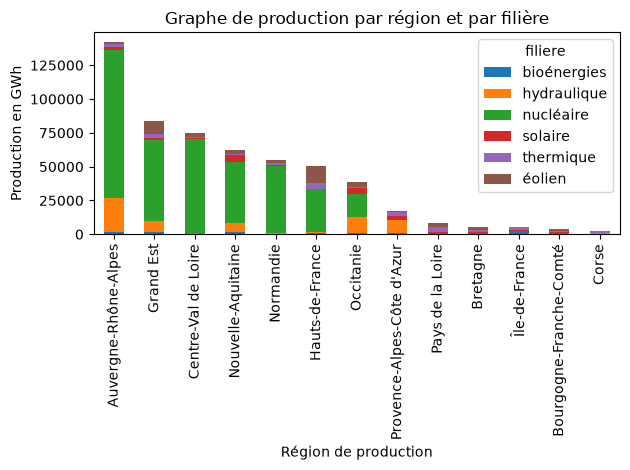

In [15]:
# votre code
croise["total"]=croise.sum(axis=1)
croise = croise.sort_values(by=["total"], ascending=False)
croise = croise.drop(columns="total")
ax = croise.plot.bar(stacked=True)
ax.set_title("Graphe de production par région et par filière")
ax.set_ylabel("Production en GWh")
ax.set_xlabel("Région de production")
plt.tight_layout()
plt.savefig("energie.png", dpi=120)
plt.show()

In [16]:
assert os.path.exists("energie.png")
print("ok")

ok


## Exercice 5 – Production par habitant (6 pts)

**5.a** Lisez `data/population-regions.csv` dans `pop`, puis fusionnez-le avec `total` afin d'obtenir une `DataFrame` `par_hab` à 13 lignes, aux colonnes `region`, `production_gwh` et `population`. Un indice : `merge` travaille sur deux `DataFrame`, or `total` est une `Series` indexée par la région — il faudra donc commencer par la remettre en forme (la clé de fusion est `region`).

In [17]:
# votre code
pop = pd.read_csv("data/population-regions.csv", sep=";", index_col="region")
par_hab = pd.merge(pop,total, left_index=True, right_index=True)
par_hab = par_hab.reset_index()

In [18]:
assert par_hab.shape == (13, 3)
assert set(par_hab.columns) == {"region", "production_gwh", "population"}
assert par_hab["population"].sum() == 65_780_000
print("ok")

ok


**5.b** Ajoutez la colonne `kwh_par_habitant`, c'est-à-dire la production annuelle par habitant, exprimée en kWh (1 GWh = 10⁶ kWh), puis triez `par_hab` par ordre décroissant de cette colonne. Quelle région produit le plus d'électricité par habitant ? le moins ? Quel est le rapport entre les deux ?

In [19]:
# votre code
par_hab["kwh_par_habitant"]=(par_hab["production_gwh"]/par_hab["population"])*(10**6)
par_hab.sort_values(by="kwh_par_habitant", ascending=False, inplace=True)
par_hab

,region,population,production_gwh,kwh_par_habitant
3,Centre-Val de Loire,2570000,74950,29163.424125
0,Auvergne-Rhône-Alpes,8200000,142200,17341.463415
8,Normandie,3300000,54900,16636.363636
5,Grand Est,5560000,84000,15107.913669
9,Nouvelle-Aquitaine,6100000,62400,10229.508197
6,Hauts-de-France,6000000,50310,8385.000000
10,Occitanie,6100000,38800,6360.655738
4,Corse,350000,2190,6257.142857
12,Provence-Alpes-Côte d'Azur,5200000,16900,3250.000000
11,Pays de la Loire,3900000,8100,2076.923077


In [20]:
assert par_hab["kwh_par_habitant"].is_monotonic_decreasing
assert par_hab.iloc[0]["region"] == "Centre-Val de Loire"
assert abs(par_hab.iloc[0]["kwh_par_habitant"] - 29163) < 1
assert par_hab.iloc[-1]["region"] == "Île-de-France"
assert abs(par_hab.iloc[-1]["kwh_par_habitant"] - 443) < 1
print("ok")

ok


**5.c** Avec `pd.cut`, ajoutez une colonne `classe` qui range chaque région dans l'une des trois catégories `"faible"` (moins de 3 000 kWh/hab), `"moyenne"` (de 3 000 à 10 000) ou `"forte"` (plus de 10 000). Comptez les régions de chaque classe, puis affichez la production moyenne par habitant de chaque classe (sur une colonne catégorielle, `groupby` demande `observed=True`).

In [21]:
# votre code
par_hab["classe"] = pd.cut(par_hab["kwh_par_habitant"], [0,3000,10000,par_hab["kwh_par_habitant"].max()], labels=["faible", "moyenne", "forte"])

In [22]:
assert par_hab["classe"].dtype.name == "category"
assert par_hab["classe"].value_counts().to_dict() == {"forte": 5, "faible": 4, "moyenne": 4}
assert par_hab.set_index("region").loc["Corse", "classe"] == "moyenne"
print("ok")

ok


**5.d** Exportez `par_hab` (colonnes `region`, `kwh_par_habitant` arrondi à l'entier, `classe`) dans `energie-par-habitant.csv`, avec `;` comme séparateur et **sans** la colonne d'index. Relisez le fichier pour vérifier qu'il a bien 13 lignes et 3 colonnes.

In [23]:
# votre code
par_hab["kwh_par_habitant"] = par_hab["kwh_par_habitant"].astype(int)
par_hab.to_csv("energie-par-habitant.csv", sep=";", columns = ["region", "kwh_par_habitant", "classe"], index = False)
verif = pd.read_csv("energie-par-habitant.csv", sep=";")
verif

,region,kwh_par_habitant,classe
0,Centre-Val de Loire,29163,forte
1,Auvergne-Rhône-Alpes,17341,forte
2,Normandie,16636,forte
3,Grand Est,15107,forte
4,Nouvelle-Aquitaine,10229,forte
5,Hauts-de-France,8385,moyenne
6,Occitanie,6360,moyenne
7,Corse,6257,moyenne
8,Provence-Alpes-Côte d'Azur,3250,moyenne
9,Pays de la Loire,2076,faible


In [24]:
verif = pd.read_csv("energie-par-habitant.csv", sep=";")
assert verif.shape == (13, 3)
assert list(verif.columns) == ["region", "kwh_par_habitant", "classe"]
assert verif["kwh_par_habitant"].dtype.kind in "iu"
print("ok")

ok


## Bonus (+2)

**Bo.1** La part renouvelable d'une région est la part (en %) de hydraulique + éolien + solaire + bioénergies dans sa production totale. Calculez la `Series` `part_renouvelable` et affichez-la triée. Quelle région est la plus "verte" en proportion ? Cette lecture est-elle trompeuse ? Répondez en une phrase, en regardant les GWh.

**Bo.2** Ajoutez à `croise` une ligne `"France"` contenant les totaux par filière, avec `pd.concat` (il faut construire une `DataFrame` d'une seule ligne). Vérifiez que la nouvelle table a 14 lignes et que sa dernière ligne vaut bien `total.sum()`.

In [25]:
# votre code
part_renouvelable = round((croise["hydraulique"] + croise["éolien"] + croise["solaire"] + croise["bioénergies"])/total*100, 2)
part_renouvelable = part_renouvelable.sort_values(ascending=False)
print(part_renouvelable)
print(total)

region
Bourgogne-Franche-Comté       92.31
Provence-Alpes-Côte d'Azur    79.29
Bretagne                      78.95
Pays de la Loire              56.79
Occitanie                     54.90
Île-de-France                 54.13
Corse                         45.21
Hauts-de-France               28.44
Nouvelle-Aquitaine            26.44
Grand Est                     24.40
Auvergne-Rhône-Alpes          20.89
Centre-Val de Loire            6.20
Normandie                      5.28
dtype: float64
region
Auvergne-Rhône-Alpes          142200
Grand Est                      84000
Centre-Val de Loire            74950
Nouvelle-Aquitaine             62400
Normandie                      54900
Hauts-de-France                50310
Occitanie                      38800
Provence-Alpes-Côte d'Azur     16900
Pays de la Loire                8100
Bretagne                        5700
Île-de-France                   5450
Bourgogne-Franche-Comté         3900
Corse                           2190
Name: production_gwh, 

Les régions qui ont le meilleur mix d'énergies renouvelables sont aussi les régions qui produisent le moins.A l'inverse, les régions qui produisent le plus (Auvergne-Rhone-Alpes et Grand Est) sont celles qui ont le moins bon mix d'énergies renouvelables.

In [32]:
croise2 = croise.T
croise2["France"] = croise2.sum(axis=1)
tots = croise2[["France"]].T
croise3 = pd.concat([croise,tots])
croise3
assert(croise3.shape==(14,6))
print(croise3.iloc[-1])
print(total)
assert(croise3.iloc[-1] == total)

filiere
bioénergies     12650
hydraulique     63960
nucléaire      384000
solaire         20000
thermique       25900
éolien          43290
Name: France, dtype: int64
region
Auvergne-Rhône-Alpes          142200
Grand Est                      84000
Centre-Val de Loire            74950
Nouvelle-Aquitaine             62400
Normandie                      54900
Hauts-de-France                50310
Occitanie                      38800
Provence-Alpes-Côte d'Azur     16900
Pays de la Loire                8100
Bretagne                        5700
Île-de-France                   5450
Bourgogne-Franche-Comté         3900
Corse                           2190
Name: production_gwh, dtype: int64


ValueError: Can only compare identically-labeled Series objects

Bon courage à tous ! Pour toute question sur le sujet, écrivez-moi à [aurelien.noce@minesparis.psl.eu](mailto:aurelien.noce@minesparis.psl.eu), en mettant [aurelien.noce@imagine-app.fr](mailto:aurelien.noce@imagine-app.fr) en copie : la messagerie de l'école perd parfois des mails, la seconde adresse sert de filet.

Au plaisir de vous lire,

votre responsable de cours, Aurélien Noce